In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from my_helpers.epx_specific.shared_lalent_space import BasicSharedPiplineAudio

from my_helpers.viz_helpers import plot_datasets
from my_helpers.data_helpers import set_torch_seed
import configs
import os

In [3]:
from sklearn.manifold import TSNE
import numpy as np
from matplotlib import pyplot as plt
from my_helpers.viz_helpers import extract_plot_points, plot_datasets, reduce_dimension
from my_helpers.data_helpers import combine_datasets_embeddings, make_dataset_by_context
import matplotlib as mpl



# Coss Tool

reduce dimension...
figure saved as: /Users/siliu/Desktop/KnowledgeTransferMini/1_viz_projections/input.jpeg


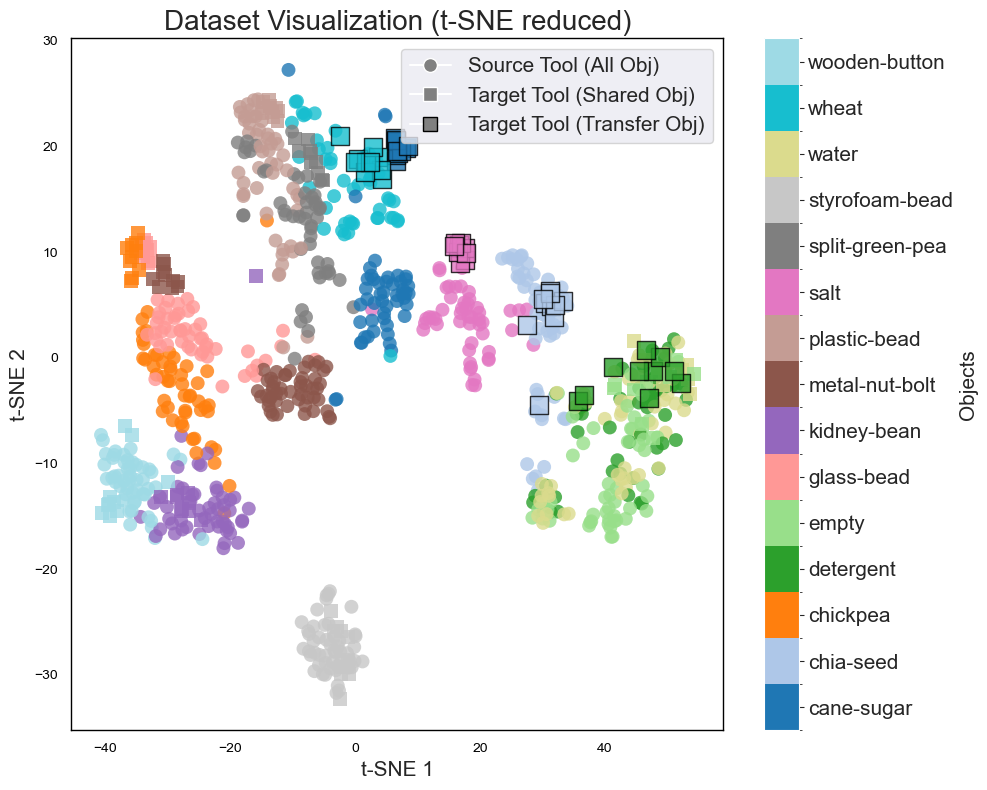

In [4]:
audio_data_name = "audio_20s_clap_emb_all.npz"
full_obj_list = configs.SORTED_OBJ_LIST
context_dict = {
    "source_tool_list": configs.source_tool_list,
    "target_tool_list": configs.target_tool_list,
    "source_beh_list": configs.source_beh_list,
    "target_beh_list": configs.target_beh_list,
    "test_object_list": configs.new_object_list,
    "shared_object_list": configs.old_object_list,
    
}
hyparams = {
    "one_batch": True,  # one batch data during training
    "shuffle": False,  # shuffle train data

    "batch_size": 128,  # doesn't matter when one_batch is True
    "epoch_encoder": 300,
    "epoch_classifier": 300,

    "lr_encoder": configs.lr_encoder,
    "lr_classifier": configs.lr_classifier,

    "temperature": 0.5,
    "encoder_input_dim": 512,
    "encoder_hidden_dim": 256,
    "encoder_output_dim": 128,
}
full_data_tsne = plot_datasets(context_dict=context_dict, 
          full_obj_list=full_obj_list, encoder=None, save_fig_path=os.getcwd(), save_name="input.jpeg")

## sincere

In [21]:
set_torch_seed()
pipeline = BasicSharedPiplineAudio(
        context_dict=context_dict,
        audio_data_name=audio_data_name
    )
enc_result = pipeline.train_encoder(hyparams=hyparams, one_batch=hyparams['one_batch'], full_obj_list=full_obj_list)

encoder train size: 850


reduce dimension...
figure saved as: /Users/siliu/Desktop/KnowledgeTransferMini/1_viz_projections/proj_sincere.jpeg


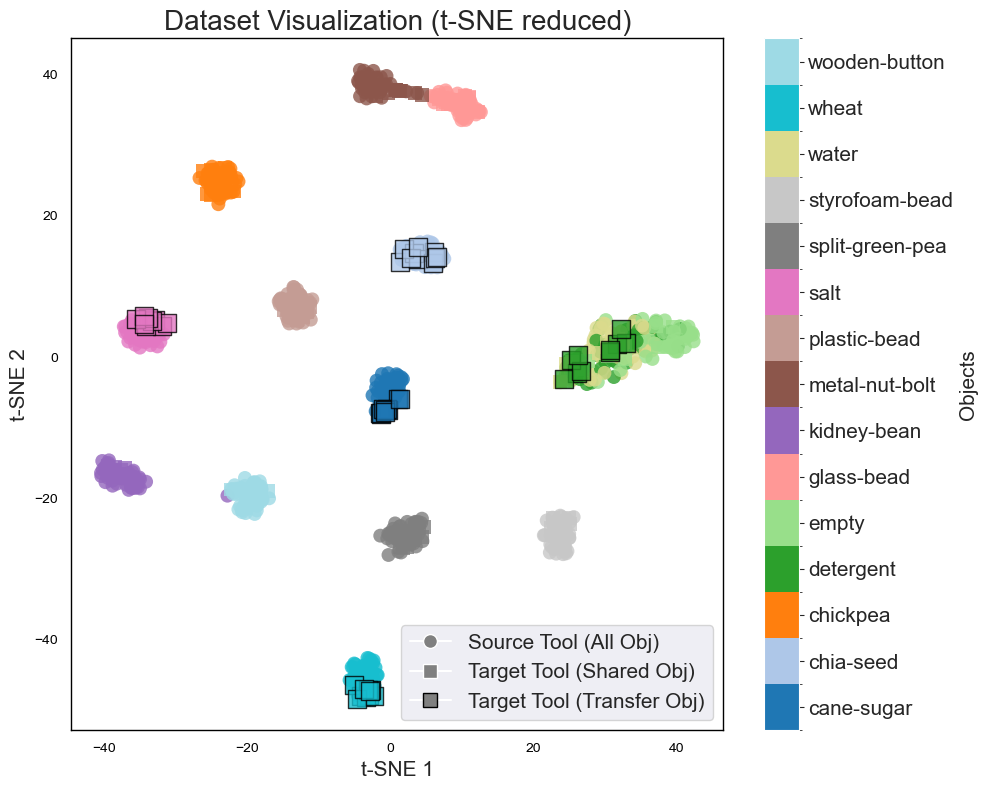

In [22]:

plot_datasets(context_dict=pipeline.context_dict, full_obj_list=full_obj_list, 
              encoder=pipeline.encoder,
              save_fig_path=os.getcwd(), save_name="proj_sincere.jpeg")


##  CLAP

In [5]:
from my_helpers.epx_specific.novel_obj_clap import ClapCrossObjPiplineAudio

text_data_name = "clap_text_emb_all.npz"
clap_pipeline = ClapCrossObjPiplineAudio(
    context_dict=context_dict,
    audio_data_name=audio_data_name,
    text_data_name=text_data_name
)
hyparams['encoder_output_dim'] = 512

In [6]:
set_torch_seed()
enc_result = clap_pipeline.learn_encoder(hyparams=hyparams,
                                         one_batch=hyparams['one_batch'],
                                         full_obj_list=full_obj_list)

encoder train size: 500


reduce dimension...
figure saved as: /Users/siliu/Desktop/KnowledgeTransferMini/1_viz_projections/proj_clap_0shot.jpeg


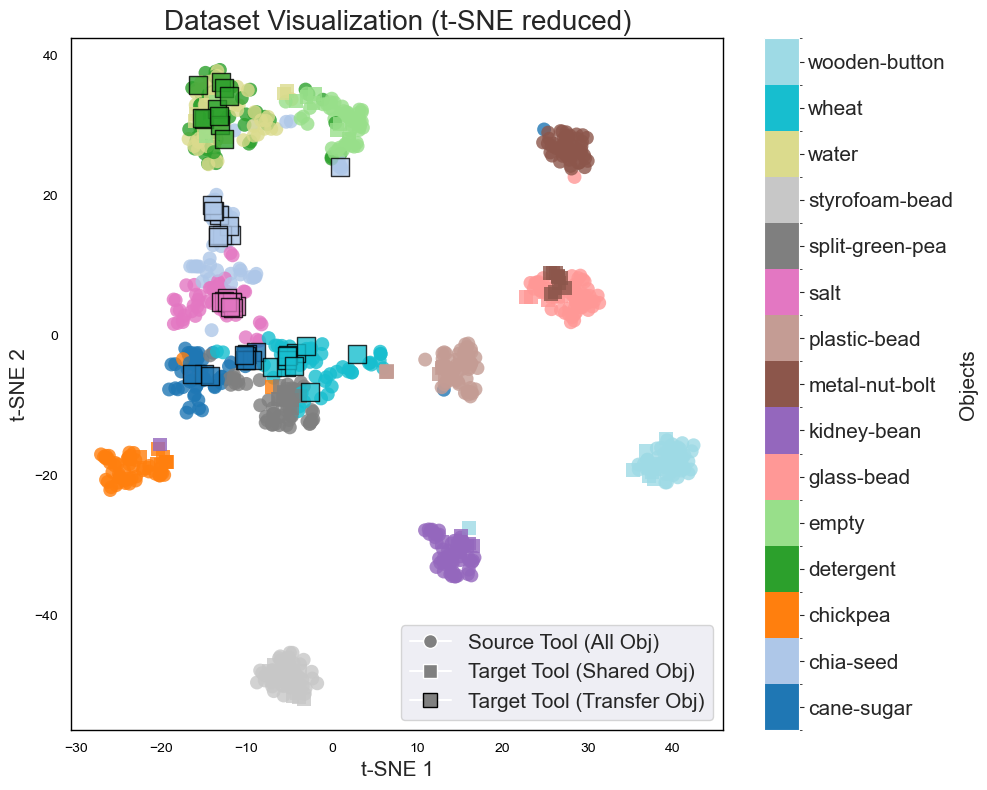

In [7]:
import os

plot_datasets(context_dict=context_dict, full_obj_list=full_obj_list, 
              encoder=clap_pipeline.encoder,
              save_fig_path=os.getcwd(), save_name="proj_clap_0shot.jpeg")


reduce dimension...
figure saved as: /Users/siliu/Desktop/KnowledgeTransferMini/1_viz_projections/proj_clap_0shot.jpeg


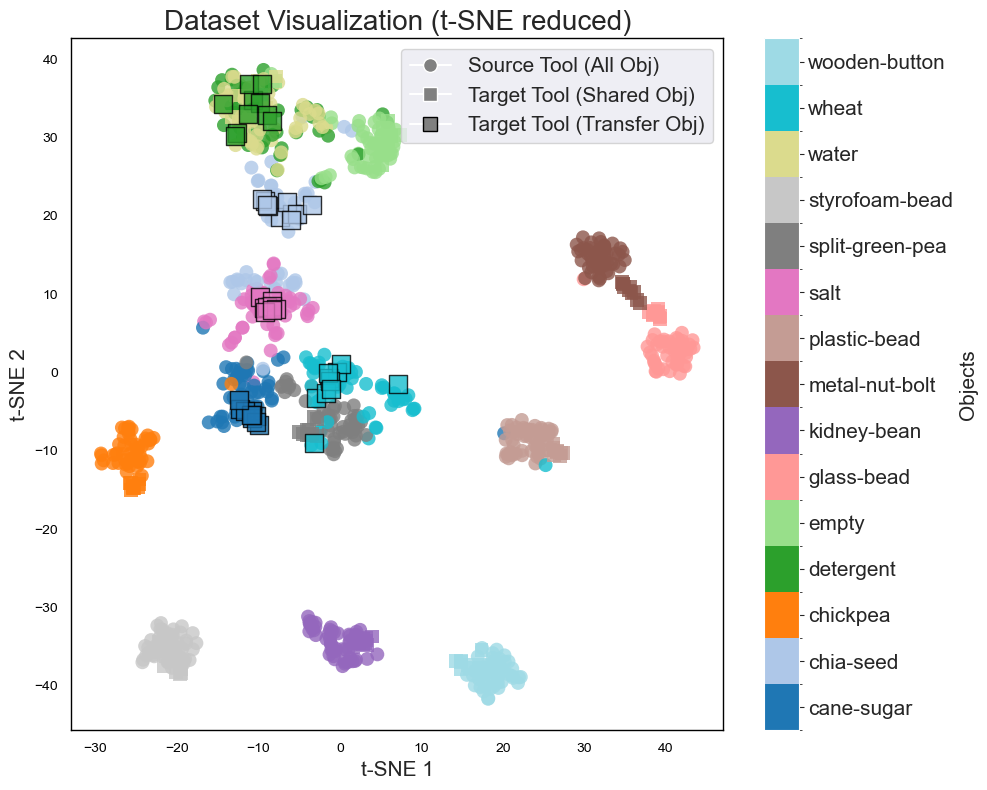

In [25]:
import os

plot_datasets(context_dict=context_dict, full_obj_list=full_obj_list, 
              encoder=clap_pipeline.encoder,
              save_fig_path=os.getcwd(), save_name="proj_clap_0shot.jpeg")


# cross behavior

In [25]:
list(set(configs.ALL_BEH_LIST) - {'4-stirring-twist'})

['3-stirring-fast', '2-stirring-slow', '5-whisk', '6-poke']

In [19]:
audio_data_name = "audio_20s_clap_emb_all.npz"
full_obj_list = configs.SORTED_OBJ_LIST
context_dict = {
    "source_tool_list": ['plastic-spoon'],
    "target_tool_list": ['plastic-spoon'],
    "source_beh_list": list(set(configs.ALL_BEH_LIST) - {'4-stirring-twist'}),
    "target_beh_list": ['4-stirring-twist'],
    "test_object_list": configs.new_object_list,
    "shared_object_list": configs.old_object_list,
    
}
hyparams = {
    "one_batch": True,  # one batch data during training
    "shuffle": False,  # shuffle train data

    "batch_size": 128,  # doesn't matter when one_batch is True
    "epoch_encoder": 300,
    "epoch_classifier": 300,

    "lr_encoder": configs.lr_encoder,
    "lr_classifier": configs.lr_classifier,

    "temperature": 0.5,
    "encoder_input_dim": 512,
    "encoder_hidden_dim": 256,
    "encoder_output_dim": 128,
}

reduce dimension...
figure saved as: /Users/siliu/Desktop/KnowledgeTransferMini/1_viz_projections/input_cross_beh.jpeg


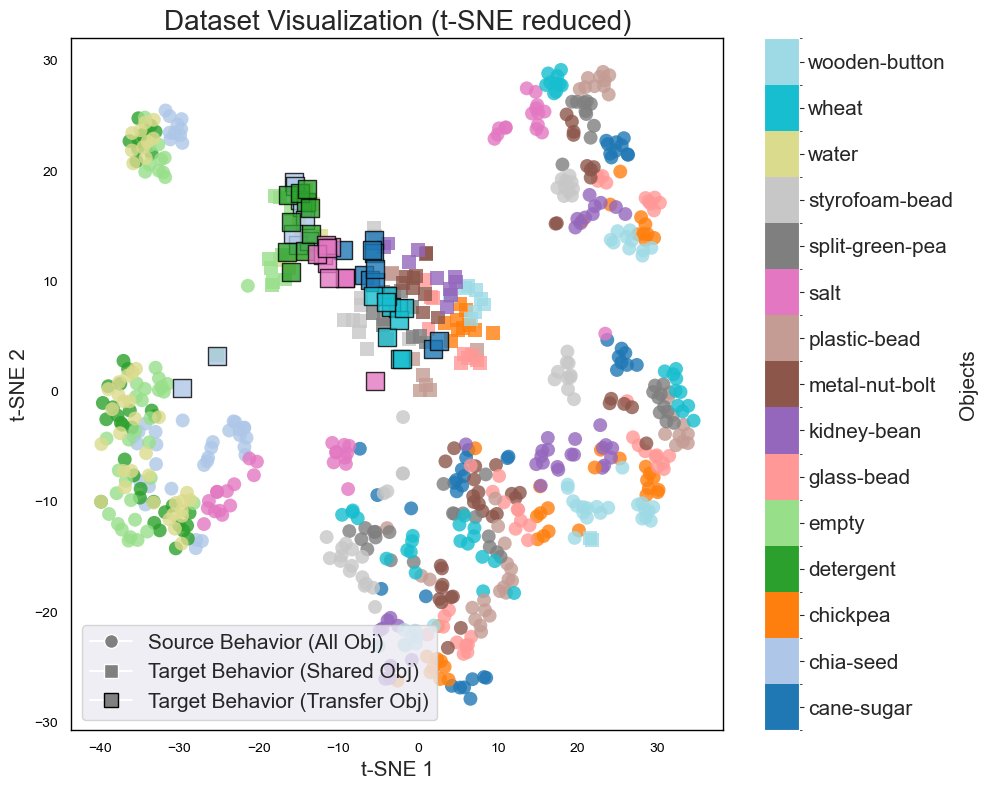

In [20]:
plot_datasets(context_dict=context_dict, 
              full_obj_list=full_obj_list, 
              encoder=None, save_fig_path=os.getcwd(), save_name="input_cross_beh.jpeg")

## sincere

In [21]:
set_torch_seed()
pipeline = BasicSharedPiplineAudio(
        context_dict=context_dict,
        audio_data_name=audio_data_name
    )
enc_result = pipeline.train_encoder(hyparams=hyparams, one_batch=hyparams['one_batch'], full_obj_list=full_obj_list)

encoder train size: 700


reduce dimension...
figure saved as: /Users/siliu/Desktop/KnowledgeTransferMini/1_viz_projections/proj_sincere_cross_beh.jpeg


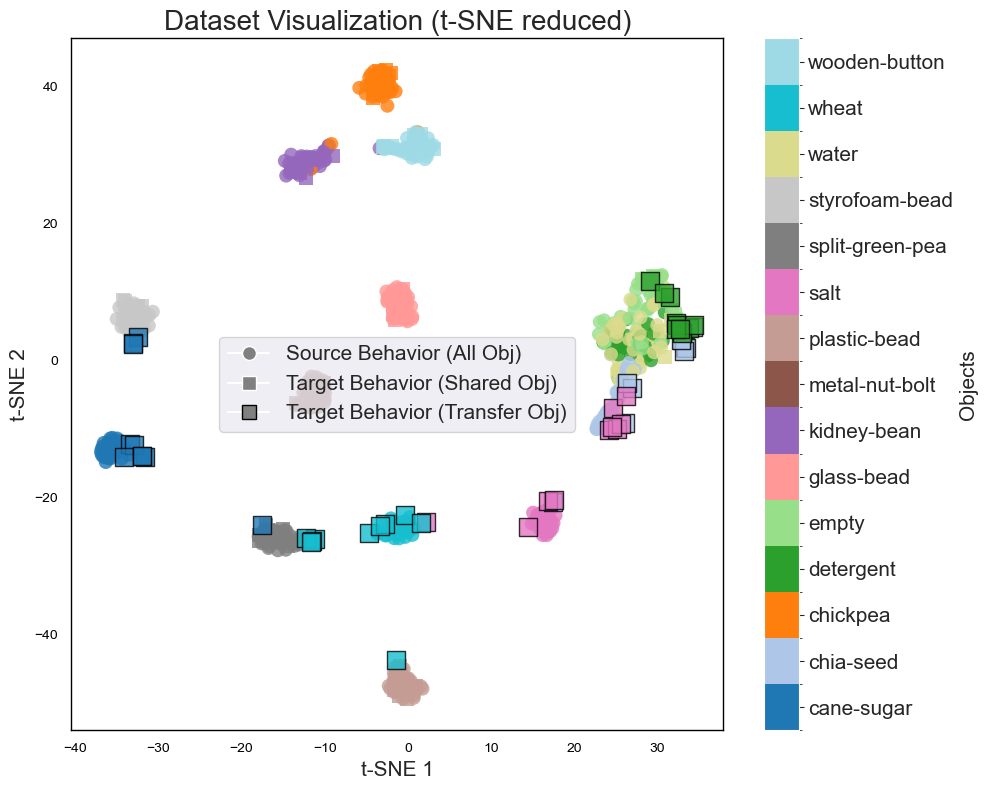

In [26]:
plot_datasets(context_dict=pipeline.context_dict, full_obj_list=full_obj_list, 
              encoder=pipeline.encoder,
              save_fig_path=os.getcwd(), save_name="proj_sincere_cross_beh.jpeg")

## clap

### all to one

In [23]:
from my_helpers.epx_specific.novel_obj_clap import ClapCrossObjPiplineAudio

text_data_name = "clap_text_emb_all.npz"
clap_pipeline = ClapCrossObjPiplineAudio(
    context_dict=context_dict,
    audio_data_name=audio_data_name,
    text_data_name=text_data_name
)
hyparams['encoder_output_dim'] = 512

set_torch_seed()
enc_result = clap_pipeline.learn_encoder(hyparams=hyparams,
                                         one_batch=hyparams['one_batch'],
                                         full_obj_list=full_obj_list)



encoder train size: 400


reduce dimension...
figure saved as: /Users/siliu/Desktop/KnowledgeTransferMini/1_viz_projections/proj_clap_0shot_cross_beh.jpeg


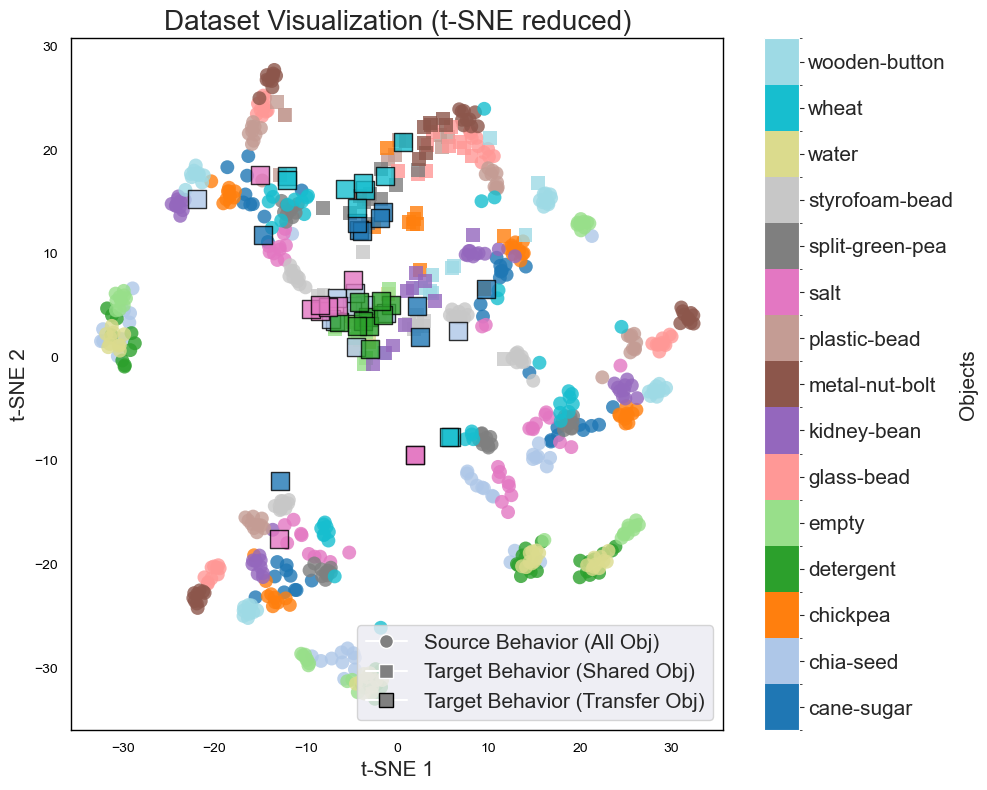

In [24]:
plot_datasets(context_dict=context_dict, full_obj_list=full_obj_list, 
              encoder=clap_pipeline.encoder,
              save_fig_path=os.getcwd(), save_name="proj_clap_0shot_cross_beh.jpeg")

reduce dimension...
figure saved as: /Users/siliu/Desktop/KnowledgeTransferMini/1_viz_projections/proj_clap_0shot_cross_beh.jpeg


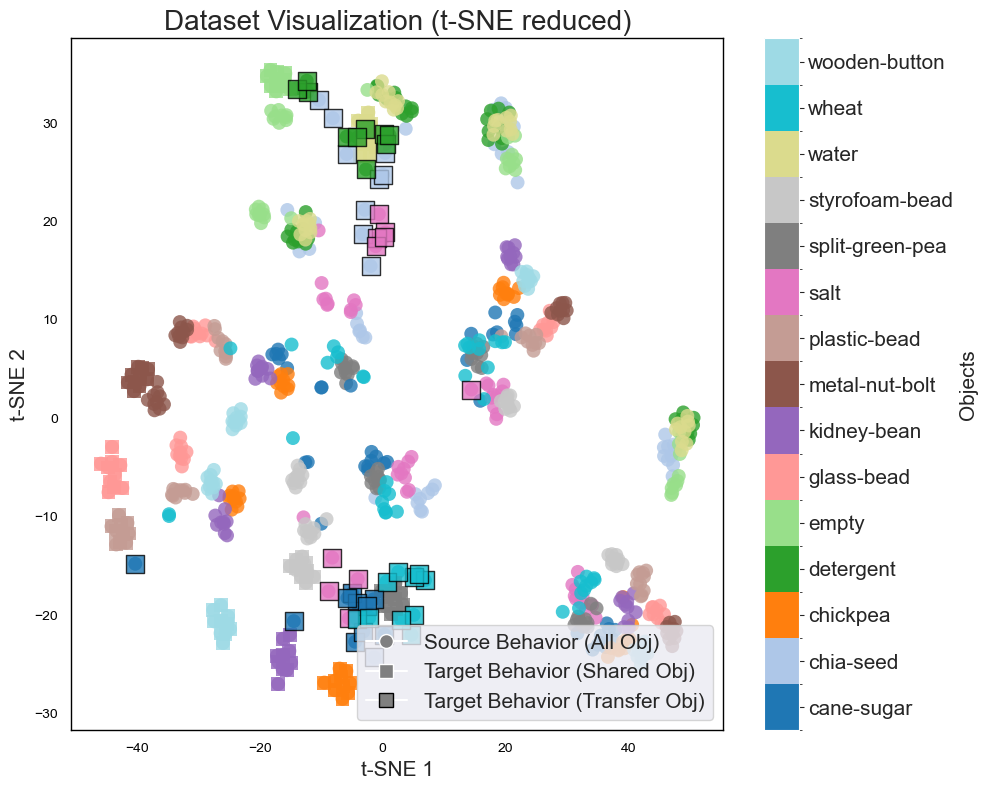

In [32]:
plot_datasets(context_dict=context_dict, full_obj_list=full_obj_list, 
              encoder=clap_pipeline.encoder,
              save_fig_path=os.getcwd(), save_name="proj_clap_0shot_cross_beh.jpeg")

### 1 to one

In [50]:
from my_helpers.epx_specific.novel_obj_clap import ClapCrossObjPiplineAudio

text_data_name = "clap_text_emb_all.npz"
context_dict['source_beh_list'] = ['2-stirring-slow']
clap_pipeline = ClapCrossObjPiplineAudio(
    context_dict=context_dict,
    audio_data_name=audio_data_name,
    text_data_name=text_data_name
)
hyparams['encoder_output_dim'] = 512

set_torch_seed()
enc_result = clap_pipeline.learn_encoder(hyparams=hyparams,
                                         one_batch=hyparams['one_batch'],
                                         full_obj_list=full_obj_list)
context_dict['source_beh_list'] = ['2-stirring-slow', '4-stirring-twist','5-whisk', '6-poke']

encoder train size: 200


reduce dimension...
figure saved as: /Users/siliu/Desktop/KnowledgeTransferMini/1_viz_projections/proj_clap_0shot_cross_beh_1to1.jpeg


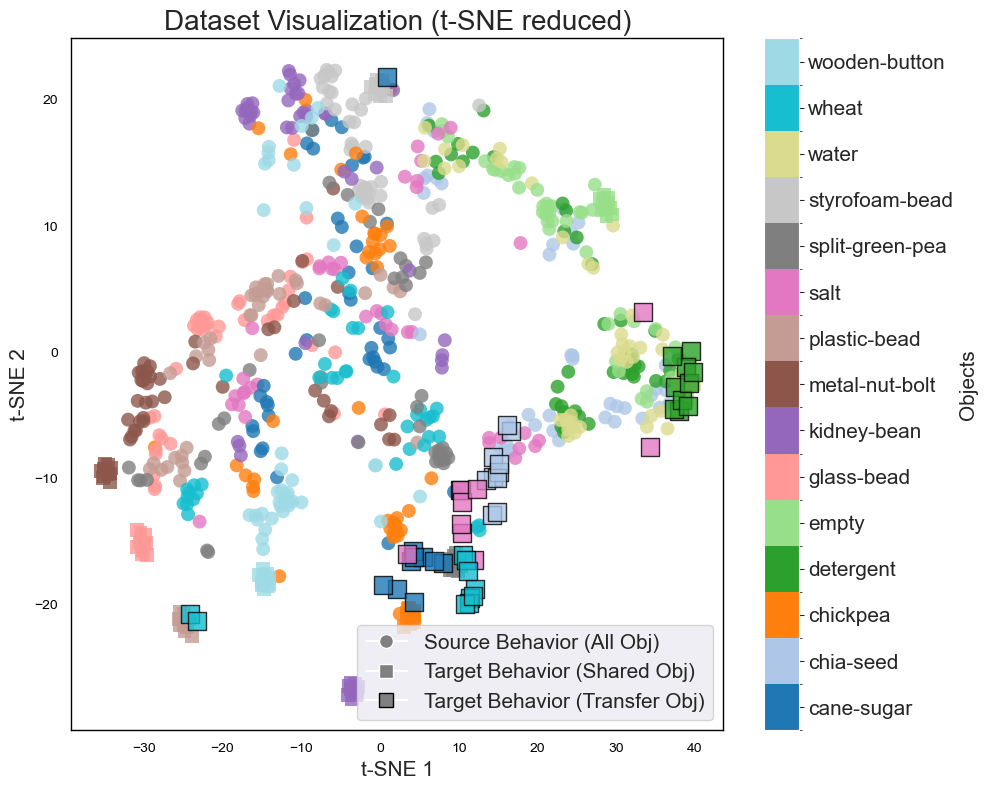

In [51]:
plot_datasets(context_dict=context_dict, full_obj_list=full_obj_list, 
              encoder=clap_pipeline.encoder,
              save_fig_path=os.getcwd(), save_name="proj_clap_0shot_cross_beh_1to1.jpeg")